# Module 04 — Optimal Trading Boundaries

This notebook validates the numerical implementation of the Leung & Li optimal
mean-reversion trading framework before it is connected to the backtester.

## Current specification

- OU process: `dX = kappa * (mu - X) dt + sigma dW`
- Stop-loss: `L = mu - k * sigma`
- Discount rate: annual continuously compounded historical risk-free rate
- Transaction costs: expressed in spread units
- Entry/exit boundaries are calculated from the optimal stopping framework,
  not arbitrary Z-score thresholds.

**Important:** the entry-boundary solver is deliberately not implemented yet.
The first objective of this notebook is to validate the liquidation-boundary
solver and inspect its numerical behaviour.

In [9]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.optimal_boundaries import (
    stop_loss_from_volatility,
    annual_discount_factor,
    fundamental_solutions,
    liquidation_objective,
    solve_liquidation_boundary,
    calculate_optimal_boundaries,
    _FundamentalBasis,
)

## 1. Test parameters

For the first validation, use a synthetic OU parameter set.

Do **not** interpret these values as the final thesis parameters. They are only
used to make sure the functions behave sensibly.

In [10]:
kappa = 0.03
mu = 0.0
sigma = 0.05

# Example annual risk-free rate.
risk_free_rate = 0.04

# Simple transaction-cost assumption in spread units.
transaction_cost = 0.001

# Baseline volatility multiplier.
stop_multiplier = 2.0

L = stop_loss_from_volatility(
    mu=mu,
    sigma=sigma,
    k=stop_multiplier,
)

print(f"OU mean-reversion speed: {kappa}")
print(f"OU long-run mean:        {mu}")
print(f"OU diffusion sigma:      {sigma}")
print(f"Stop-loss level:         {L}")

OU mean-reversion speed: 0.03
OU long-run mean:        0.0
OU diffusion sigma:      0.05
Stop-loss level:         -0.1


## 2. Discount-rate sanity check

The annual rate is **not** divided by `sqrt(252)`.

For a convergence horizon of `T` trading days:

\[
DF = e^{-rT/252}.
\]

In [11]:
expected_convergence_days = 60

df = annual_discount_factor(
    annual_rate=risk_free_rate,
    trading_days=expected_convergence_days,
)

print(f"Expected convergence: {expected_convergence_days} trading days")
print(f"Annual risk-free rate: {risk_free_rate:.2%}")
print(f"Discount factor:       {df:.8f}")

Expected convergence: 60 trading days
Annual risk-free rate: 4.00%
Discount factor:       0.99052140


## 3. Fundamental OU solutions

The fundamental solutions satisfy:

\[
\frac{\sigma^2}{2}f''(x)
+
\kappa(\mu-x)f'(x)
-rf(x)=0.
\]

The notebook plots the two numerical basis functions. Their normalization is
arbitrary; what matters for the stopping problem is that they form an
independent basis and are used consistently.

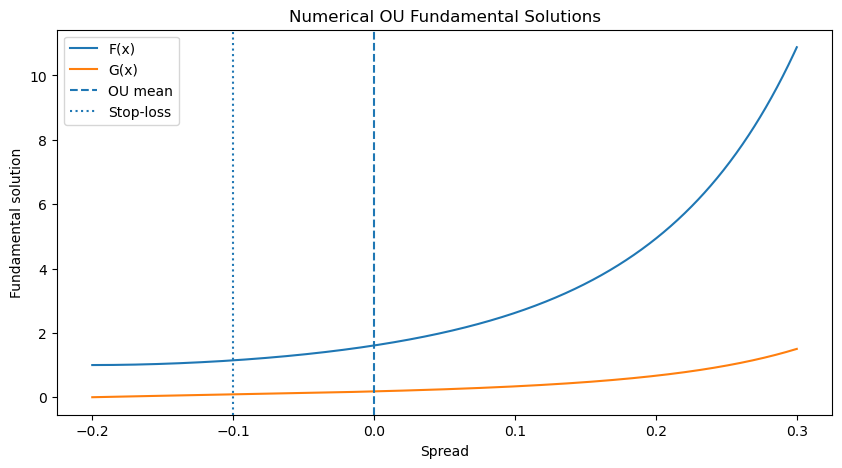

In [12]:
x_grid = np.linspace(
    mu - 4 * sigma,
    mu + 6 * sigma,
    1000,
)

F, Fp, G, Gp = fundamental_solutions(
    x=x_grid,
    kappa=kappa,
    mu=mu,
    sigma=sigma,
    r=risk_free_rate,
)

plt.figure(figsize=(10, 5))
plt.plot(x_grid, F, label="F(x)")
plt.plot(x_grid, G, label="G(x)")
plt.axvline(mu, linestyle="--", label="OU mean")
plt.axvline(L, linestyle=":", label="Stop-loss")
plt.xlabel("Spread")
plt.ylabel("Fundamental solution")
plt.title("Numerical OU Fundamental Solutions")
plt.legend()
plt.show()

## 4. Inspect the liquidation-boundary residual

Before accepting a root, inspect the residual numerically.

This is an important validation step: if the residual does not cross zero in a
reasonable region, the solver should fail rather than silently return an
arbitrary value.

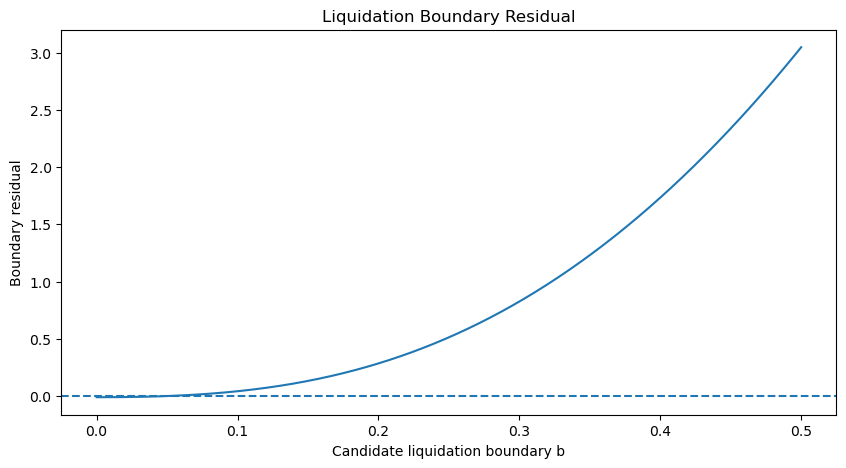

In [13]:
basis = _FundamentalBasis(
    kappa=kappa,
    mu=mu,
    sigma=sigma,
    r=risk_free_rate,
    x_min=L,
    x_max=mu + 10 * sigma,
    n_grid=2001,
)

candidate_grid = np.linspace(
    max(mu, L + 1e-8),
    mu + 10 * sigma,
    500,
)

residuals = np.array([
    liquidation_objective(
        b=b,
        basis=basis,
        L=L,
        c=transaction_cost,
    )
    for b in candidate_grid
])

plt.figure(figsize=(10, 5))
plt.plot(candidate_grid, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Candidate liquidation boundary b")
plt.ylabel("Boundary residual")
plt.title("Liquidation Boundary Residual")
plt.show()

In [14]:
b_star = solve_liquidation_boundary(
    kappa=kappa,
    mu=mu,
    sigma=sigma,
    r=risk_free_rate,
    c=transaction_cost,
    L=L,
)

print(f"Stop-loss L:             {L:.6f}")
print(f"Liquidation boundary b*: {b_star:.6f}")
print(f"b* - mu:                 {b_star - mu:.6f}")
print(f"(b* - mu) / sigma:       {(b_star - mu) / sigma:.4f}")

Stop-loss L:             -0.100000
Liquidation boundary b*: 0.049532
b* - mu:                 0.049532
(b* - mu) / sigma:       0.9906


## 5. Sensitivity to the stop-loss multiplier

The thesis baseline can use one ex-ante value of `k`, while this notebook
examines robustness.

The important point is that the stop-loss is an input to the Leung & Li
optimization; changing it should change the optimal liquidation boundary.

In [15]:
rows = []

for k in [1.0, 1.5, 2.0, 2.5, 3.0]:
    L_k = stop_loss_from_volatility(mu, sigma, k)

    b_k = solve_liquidation_boundary(
        kappa=kappa,
        mu=mu,
        sigma=sigma,
        r=risk_free_rate,
        c=transaction_cost,
        L=L_k,
    )

    rows.append({
        "stop_multiplier": k,
        "stop_loss": L_k,
        "exit_boundary": b_k,
        "exit_z_from_mu": (b_k - mu) / sigma,
    })

sensitivity = pd.DataFrame(rows)
sensitivity

,stop_multiplier,stop_loss,exit_boundary,exit_z_from_mu
0,1.0,-0.050,0.025687,0.513736
1,1.5,-0.075,0.037790,0.755803
2,2.0,-0.100,0.049532,0.990635
3,2.5,-0.125,0.060809,1.216180
4,3.0,-0.150,0.071533,1.430653


## 6. High-level function

The high-level function currently returns the stop-loss and liquidation
boundary. The entry boundary is intentionally `NaN` until its equation has
been independently validated against the paper.

This prevents the backtester from accidentally using an arbitrary entry rule.

In [16]:
result = calculate_optimal_boundaries(
    kappa=kappa,
    mu=mu,
    sigma=sigma,
    risk_free_rate=risk_free_rate,
    transaction_cost=transaction_cost,
    stop_multiplier=stop_multiplier,
)

result

OptimalBoundaries(stop_loss=-0.1, entry_boundary=nan, exit_boundary=0.04953174000952233, upper_entry_boundary=None, upper_exit_boundary=None, upper_stop_loss=None, success=True, message='Liquidation boundary solved. Entry boundary remains intentionally disabled pending validation.')